In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arunsworkspace/indian-healthcare-patient-records/Indian_healthcare.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/arunsworkspace/indian-healthcare-patient-records/Indian_healthcare.csv') 

In [3]:
df.head()

,Patient_ID,Age,Gender,Region,Socioeconomic_Status,Occupation,Visit_Date,Symptoms,Primary_Diagnosis,Blood_Glucose_mg_dL,HbA1c_%,Total_Cholesterol_mg_dL,Treatment_Type,Treatment_Outcome,Imaging_Type,Imaging_Findings,Hospital_Type,Insurance_Covered,BMI
0,21D74F65-E20,53,Female,Andhra Pradesh,Low,Clinical research associate,2025-09-18,"Fever, fatigue, increased thirst",Dengue,100.9,5.9,233.4,Lifestyle Changes,Improved,Ultrasound,Evidence of pleural effusion,Government,False,23.3
1,0BCF80B5-312,36,Male,Puducherry,Low,Agricultural consultant,2024-11-14,"Swelling in legs, high BP",Malaria,121.3,2.5,231.1,Medication,Referred,NaN,No imaging performed,Private,True,26.9
2,5EF60C7B-8E6,28,Male,Maharashtra,Low,Haematologist,2026-02-20,"Fever, fatigue, increased thirst",Hypertension,74.7,8.6,260.8,Lifestyle Changes,Improved,NaN,No imaging performed,Private,True,29.1
3,93959ACB-8BA,34,Female,Karnataka,Low,Financial risk analyst,2025-11-04,"Fever, fatigue, increased thirst",Cardiovascular Disease,102.7,5.2,244.8,Antibiotics,Referred,CT Scan,No significant abnormality detected,Government,False,26.4
4,B11DB540-128,48,Female,Puducherry,High,Environmental health practitioner,2025-08-15,"Frequent urination, blurred vision",Hypertension,61.0,6.0,280.3,Combination Therapy,Recovered,MRI,No significant abnormality detected,Government,True,33.1


In [4]:
df.dtypes

Patient_ID                  object
Age                          int64
Gender                      object
Region                      object
Socioeconomic_Status        object
Occupation                  object
Visit_Date                  object
Symptoms                    object
Primary_Diagnosis           object
Blood_Glucose_mg_dL        float64
HbA1c_%                    float64
Total_Cholesterol_mg_dL    float64
Treatment_Type              object
Treatment_Outcome           object
Imaging_Type                object
Imaging_Findings            object
Hospital_Type               object
Insurance_Covered             bool
BMI                        float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Patient_ID               100000 non-null  object 
 1   Age                      100000 non-null  int64  
 2   Gender                   100000 non-null  object 
 3   Region                   100000 non-null  object 
 4   Socioeconomic_Status     100000 non-null  object 
 5   Occupation               100000 non-null  object 
 6   Visit_Date               100000 non-null  object 
 7   Symptoms                 100000 non-null  object 
 8   Primary_Diagnosis        100000 non-null  object 
 9   Blood_Glucose_mg_dL      100000 non-null  float64
 10  HbA1c_%                  100000 non-null  float64
 11  Total_Cholesterol_mg_dL  100000 non-null  float64
 12  Treatment_Type           100000 non-null  object 
 13  Treatment_Outcome        100000 non-null  object 
 14  Imagi

In [6]:
df.describe()

,Age,Blood_Glucose_mg_dL,HbA1c_%,Total_Cholesterol_mg_dL,BMI
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,44.45240,127.698071,6.397020,216.142810,24.557908
std,17.90413,46.745102,1.776399,43.432516,5.300243
min,1.00000,-11.700000,0.200000,48.400000,15.000000
25%,32.00000,95.800000,5.200000,186.600000,20.800000
50%,44.00000,118.900000,6.100000,215.200000,24.500000
75%,57.00000,150.600000,7.300000,244.700000,28.200000
max,95.00000,349.500000,15.300000,411.200000,45.000000


In [7]:
df.isnull().sum()

Patient_ID                     0
Age                            0
Gender                         0
Region                         0
Socioeconomic_Status           0
Occupation                     0
Visit_Date                     0
Symptoms                       0
Primary_Diagnosis              0
Blood_Glucose_mg_dL            0
HbA1c_%                        0
Total_Cholesterol_mg_dL        0
Treatment_Type                 0
Treatment_Outcome              0
Imaging_Type               35031
Imaging_Findings               0
Hospital_Type                  0
Insurance_Covered              0
BMI                            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Patient_ID                  object
Age                          int64
Gender                      object
Region                      object
Socioeconomic_Status        object
Occupation                  object
Visit_Date                  object
Symptoms                    object
Primary_Diagnosis           object
Blood_Glucose_mg_dL        float64
HbA1c_%                    float64
Total_Cholesterol_mg_dL    float64
Treatment_Type              object
Treatment_Outcome           object
Imaging_Type                object
Imaging_Findings            object
Hospital_Type               object
Insurance_Covered             bool
BMI                        float64
dtype: object

In [10]:
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])

In [11]:
df.dtypes

Patient_ID                         object
Age                                 int64
Gender                             object
Region                             object
Socioeconomic_Status               object
Occupation                         object
Visit_Date                 datetime64[ns]
Symptoms                           object
Primary_Diagnosis                  object
Blood_Glucose_mg_dL               float64
HbA1c_%                           float64
Total_Cholesterol_mg_dL           float64
Treatment_Type                     object
Treatment_Outcome                  object
Imaging_Type                       object
Imaging_Findings                   object
Hospital_Type                      object
Insurance_Covered                    bool
BMI                               float64
dtype: object

**Missing Values**

In [12]:
df[df['Imaging_Type'].isnull()][['Imaging_Type','Imaging_Findings']].head(10)

,Imaging_Type,Imaging_Findings
1,NaN,No imaging performed
2,NaN,No imaging performed
6,NaN,No imaging performed
10,NaN,No imaging performed
11,NaN,No imaging performed
12,NaN,No imaging performed
15,NaN,No imaging performed
17,NaN,No imaging performed
18,NaN,No imaging performed
21,NaN,No imaging performed


In [13]:
df['Imaging_Type'] = df['Imaging_Type'].fillna('No imaging')

In [14]:
df['Imaging_Type'].isnull().sum()

np.int64(0)

In [15]:
df[df['Blood_Glucose_mg_dL']<0]

,Patient_ID,Age,Gender,Region,Socioeconomic_Status,Occupation,Visit_Date,Symptoms,Primary_Diagnosis,Blood_Glucose_mg_dL,HbA1c_%,Total_Cholesterol_mg_dL,Treatment_Type,Treatment_Outcome,Imaging_Type,Imaging_Findings,Hospital_Type,Insurance_Covered,BMI
15239,2B994C4B-992,49,Male,Tamil Nadu,Low,"Education officer, environmental",2024-12-10,"Headache, joint pain, high fever",Asthma/COPD,-1.9,6.0,233.2,Surgery,Recovered,CT Scan,Fatty liver changes,Government,False,25.8
53746,D84BC8CF-B5B,60,Male,Maharashtra,Low,Retail buyer,2025-06-12,"Cough, weight loss, night sweats",Thyroid Disorder,-7.4,5.7,160.3,Antibiotics,Stable,No imaging,No imaging performed,Private,False,22.9
69882,0797F21E-A8C,46,Male,Puducherry,Middle,Air cabin crew,2025-05-31,"Frequent urination, blurred vision",Chronic Kidney Disease,-8.3,4.1,224.7,Surgery,Worsened,No imaging,No imaging performed,Private,True,24.7
75558,C7628B70-8C2,12,Female,Kerala,Low,Health visitor,2025-07-27,"Cough, weight loss, night sweats",Malaria,-2.8,5.7,206.1,Antibiotics,Improved,No imaging,No imaging performed,Private,True,32.9
94581,23F316BC-C9C,42,Male,Kerala,Middle,Print production planner,2026-04-24,"Chest pain, shortness of breath",Chronic Kidney Disease,-11.7,3.2,148.5,Surgery,Stable,Ultrasound,Mild cardiomegaly observed,Government,False,27.8
98561,1343ACE7-F60,84,Male,Tamil Nadu,Middle,Investment analyst,2024-12-22,"Frequent urination, blurred vision",Thyroid Disorder,-8.5,3.4,225.5,Medication,Improved,CT Scan,No significant abnormality detected,Government,True,29.3


In [16]:
(df["Blood_Glucose_mg_dL"]<0).sum() 

np.int64(6)

In [17]:
import numpy as np
df.loc[df['Blood_Glucose_mg_dL']<0,"Blood_Glucose_mg_dL"] = np.nan


**7. Exploratory Data Analysis (EDA)**

In [18]:
df['Age'].describe()

count    100000.00000
mean         44.45240
std          17.90413
min           1.00000
25%          32.00000
50%          44.00000
75%          57.00000
max          95.00000
Name: Age, dtype: float64

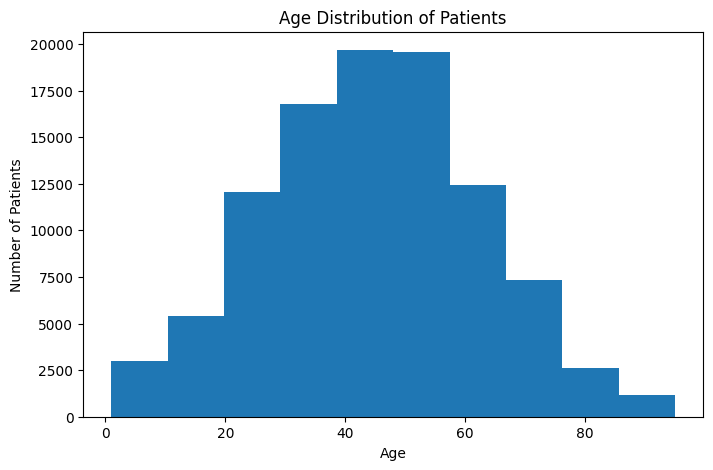

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


**Gender Distribution**



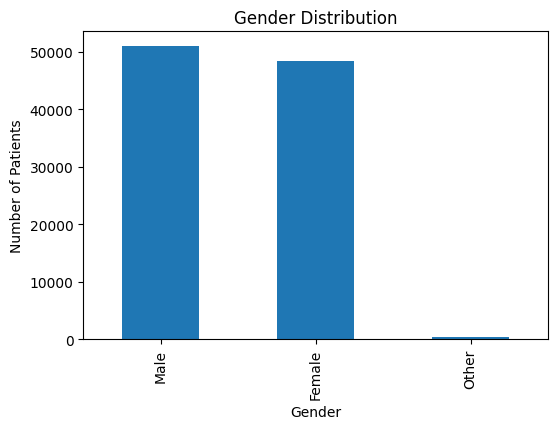

In [20]:
df["Gender"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Gender Distribution"
)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

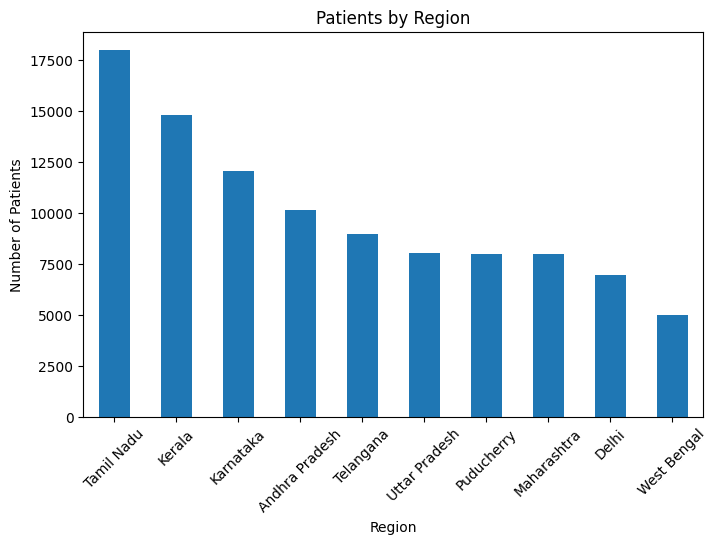

In [21]:
df["Region"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Patients by Region"
)

plt.xlabel("Region")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

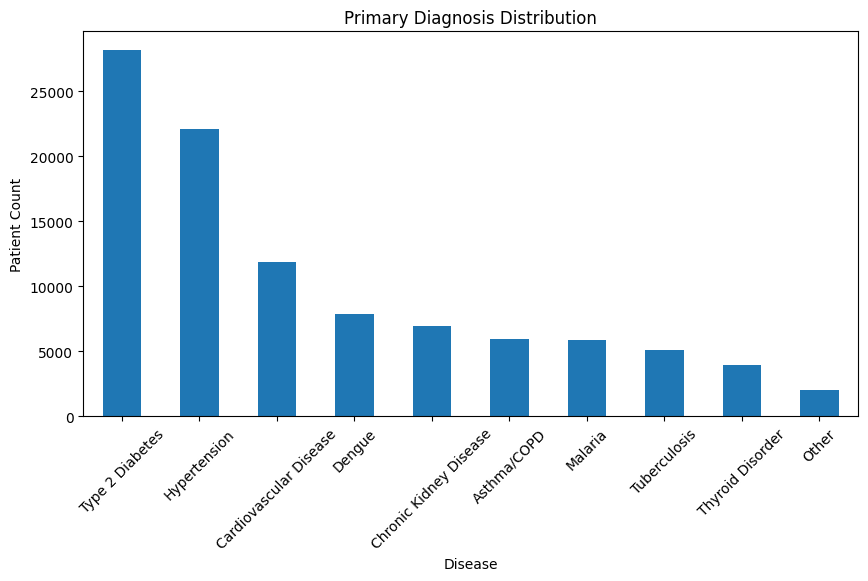

In [22]:
df["Primary_Diagnosis"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    title="Primary Diagnosis Distribution"
)

plt.xlabel("Disease")
plt.ylabel("Patient Count")
plt.xticks(rotation=45)
plt.show()

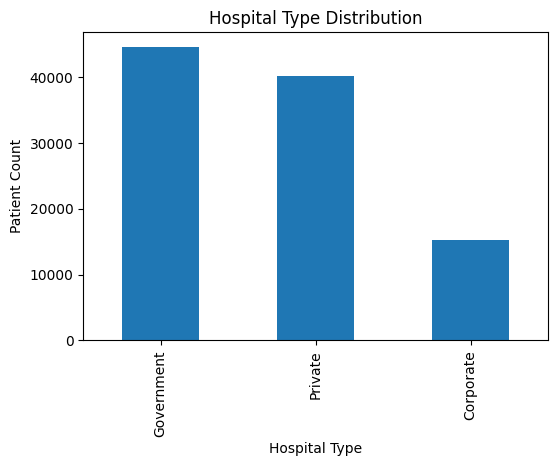

In [23]:
df["Hospital_Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Hospital Type Distribution"
)

plt.xlabel("Hospital Type")
plt.ylabel("Patient Count")
plt.show()

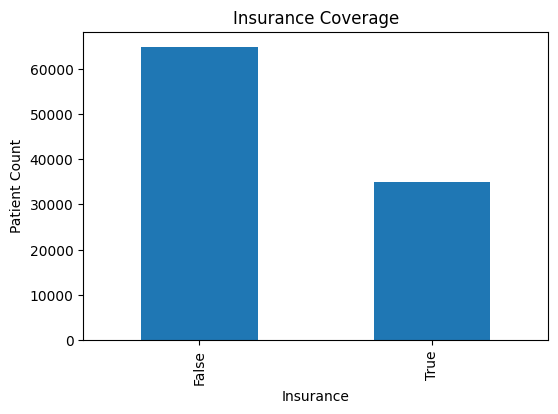

In [24]:
df["Insurance_Covered"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Insurance Coverage"
)

plt.xlabel("Insurance")
plt.ylabel("Patient Count")
plt.show()

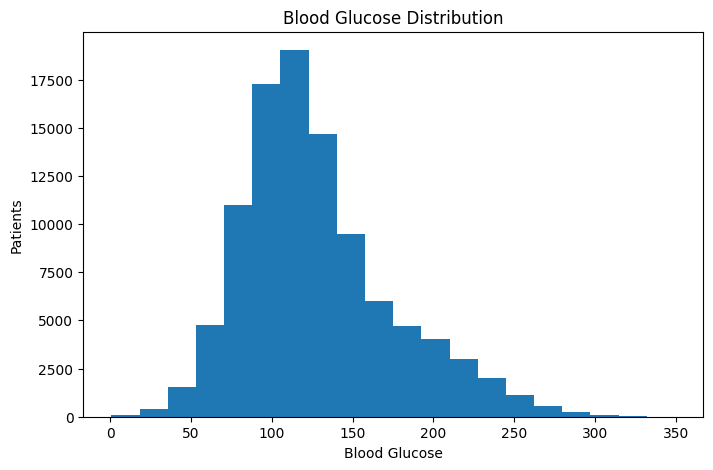

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["Blood_Glucose_mg_dL"], bins=20)
plt.title("Blood Glucose Distribution")
plt.xlabel("Blood Glucose")
plt.ylabel("Patients")
plt.show()

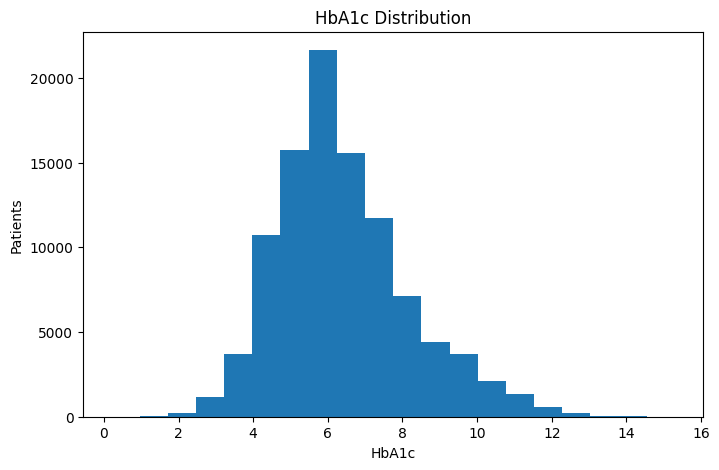

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df["HbA1c_%"], bins=20)
plt.title("HbA1c Distribution")
plt.xlabel("HbA1c")
plt.ylabel("Patients")
plt.show()

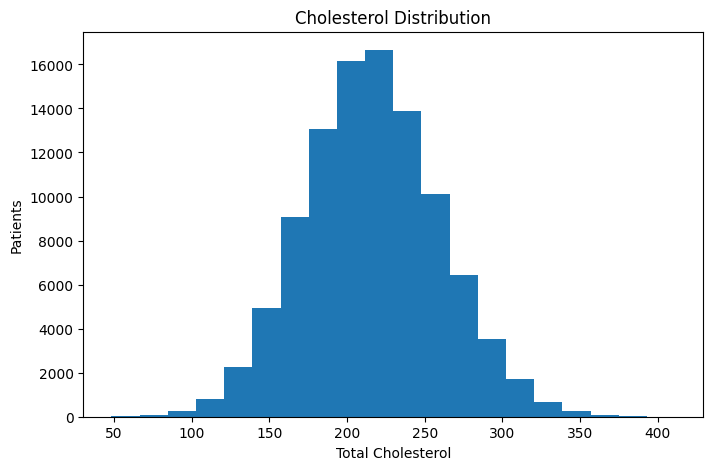

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Cholesterol_mg_dL"], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Total Cholesterol")
plt.ylabel("Patients")
plt.show()

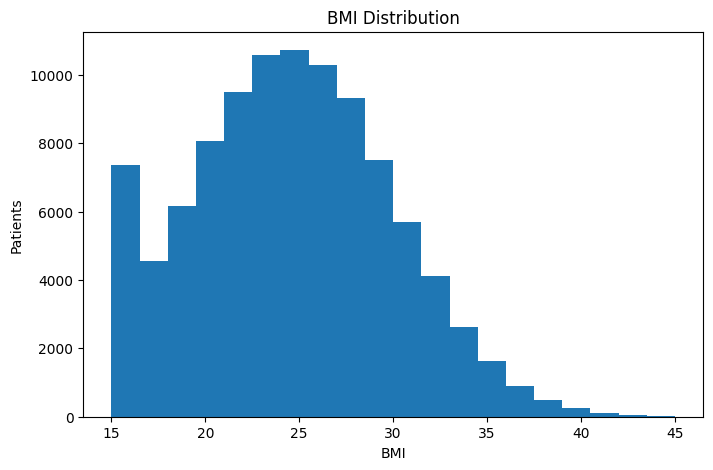

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Patients")
plt.show()

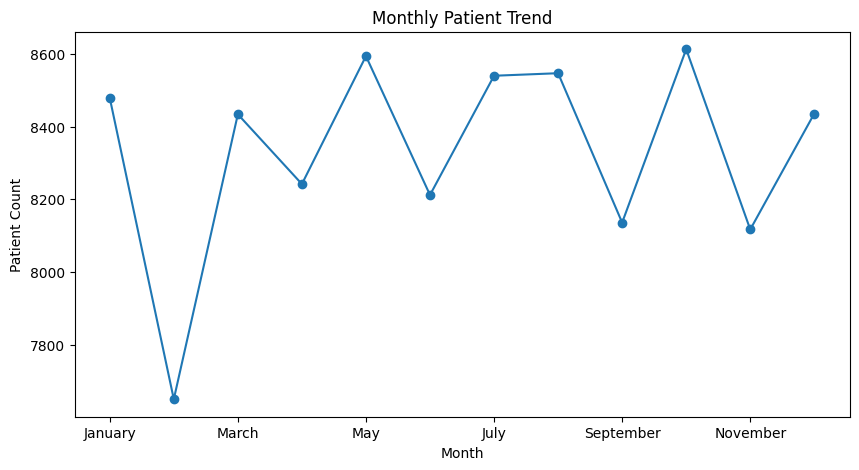

In [29]:
df["Month"] = df["Visit_Date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df["Month"].value_counts().reindex(month_order)

monthly.plot(
    kind="line",
    marker="o",
    figsize=(10,5),
    title="Monthly Patient Trend"
)

plt.xlabel("Month")
plt.ylabel("Patient Count")
plt.show()

****8.1 Disease Distribution by Gender****

In [30]:
pd.crosstab(df["Gender"], df["Primary_Diagnosis"])

Primary_Diagnosis,Asthma/COPD,Cardiovascular Disease,Chronic Kidney Disease,Dengue,Hypertension,Malaria,Other,Thyroid Disorder,Tuberculosis,Type 2 Diabetes
Gender,,,,,,,,,,
Female,2894,5815,3395,3800,10623,2859,987,1920,2508,13693
Male,3055,6015,3548,4077,11346,3015,1016,2019,2551,14371
Other,32,59,29,33,117,24,13,20,16,150


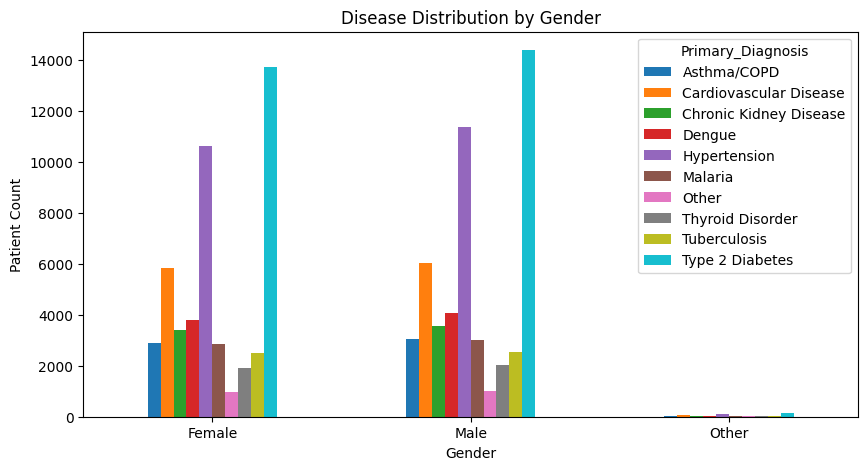

In [31]:
pd.crosstab(df["Gender"], df["Primary_Diagnosis"]).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Patient Count")
plt.xticks(rotation=0)
plt.show()

**8.2 Disease Distribution by Region**

In [32]:
pd.crosstab(df["Region"], df["Primary_Diagnosis"])

Primary_Diagnosis,Asthma/COPD,Cardiovascular Disease,Chronic Kidney Disease,Dengue,Hypertension,Malaria,Other,Thyroid Disorder,Tuberculosis,Type 2 Diabetes
Region,,,,,,,,,,
Andhra Pradesh,604,1253,727,789,2235,608,210,384,510,2820
Delhi,396,827,465,577,1570,405,144,290,329,1979
Karnataka,718,1389,810,918,2616,730,248,501,634,3485
Kerala,909,1740,1061,1142,3328,885,265,564,771,4129
Maharashtra,494,1033,528,637,1747,473,169,310,389,2226
Puducherry,498,970,536,640,1757,429,162,319,393,2304
Tamil Nadu,1037,2089,1286,1404,3939,1080,372,689,951,5155
Telangana,571,1067,611,735,1933,539,183,382,465,2489
Uttar Pradesh,440,957,601,668,1830,453,161,319,374,2253


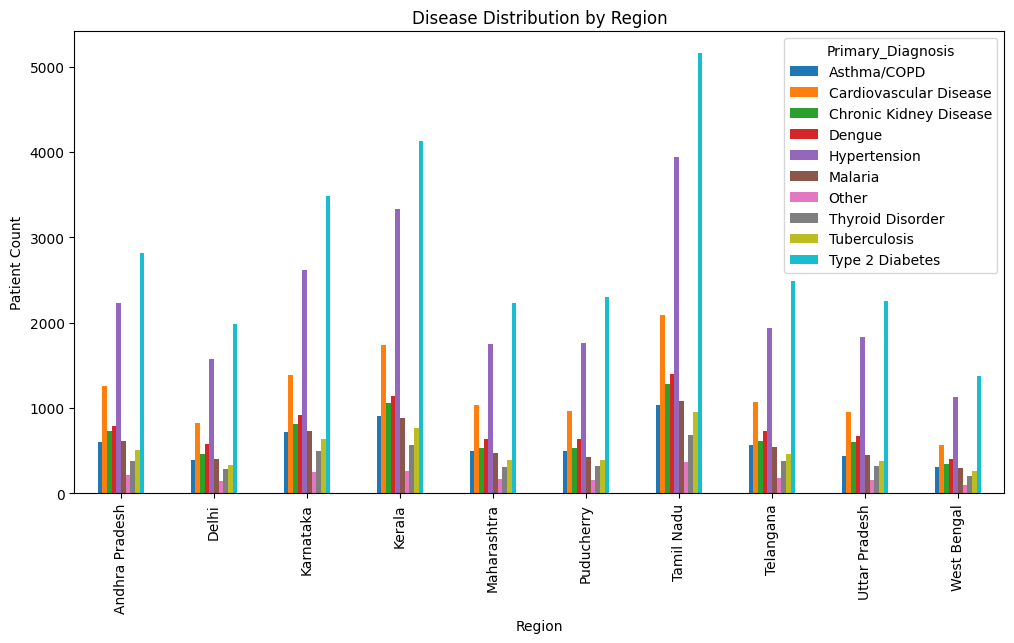

In [33]:
pd.crosstab(df["Region"], df["Primary_Diagnosis"]).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Disease Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Patient Count")
plt.show()

**8.3 Treatment Outcome by Hospital Type**

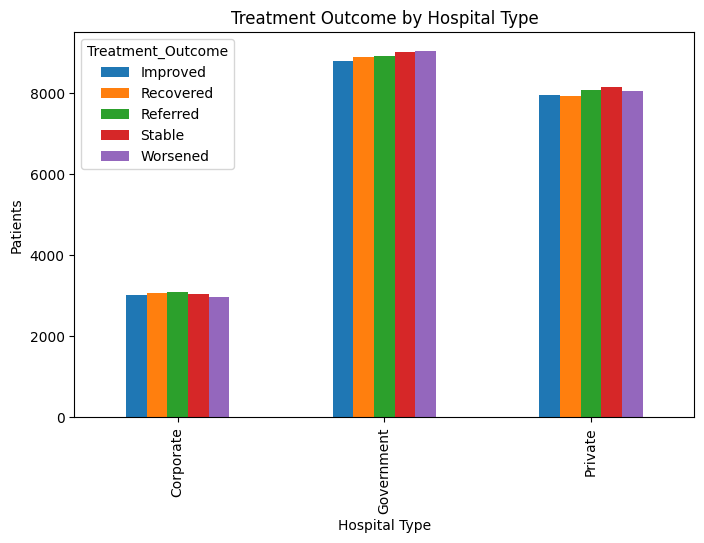

In [34]:
pd.crosstab(df["Hospital_Type"], df["Treatment_Outcome"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Treatment Outcome by Hospital Type")
plt.xlabel("Hospital Type")
plt.ylabel("Patients")
plt.show()

8.4 Insurance Coverage by Hospital Type

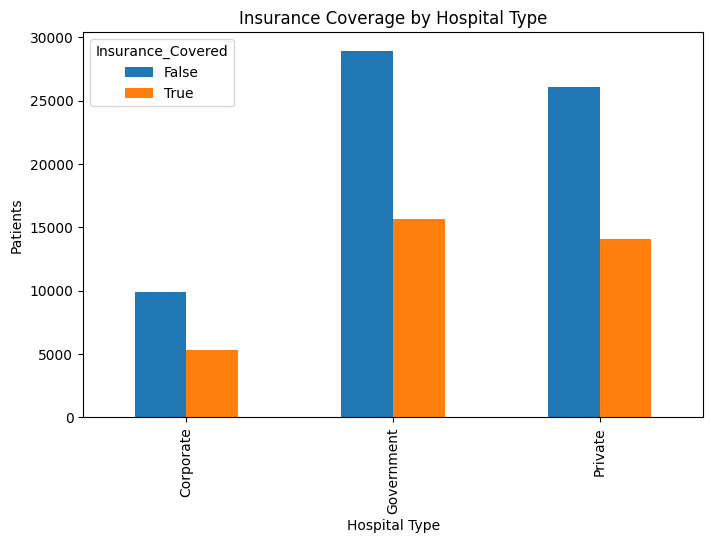

In [35]:
pd.crosstab(df["Hospital_Type"], df["Insurance_Covered"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Insurance Coverage by Hospital Type")
plt.xlabel("Hospital Type")
plt.ylabel("Patients")
plt.show()

**8.5 Average Blood Glucose by Disease**

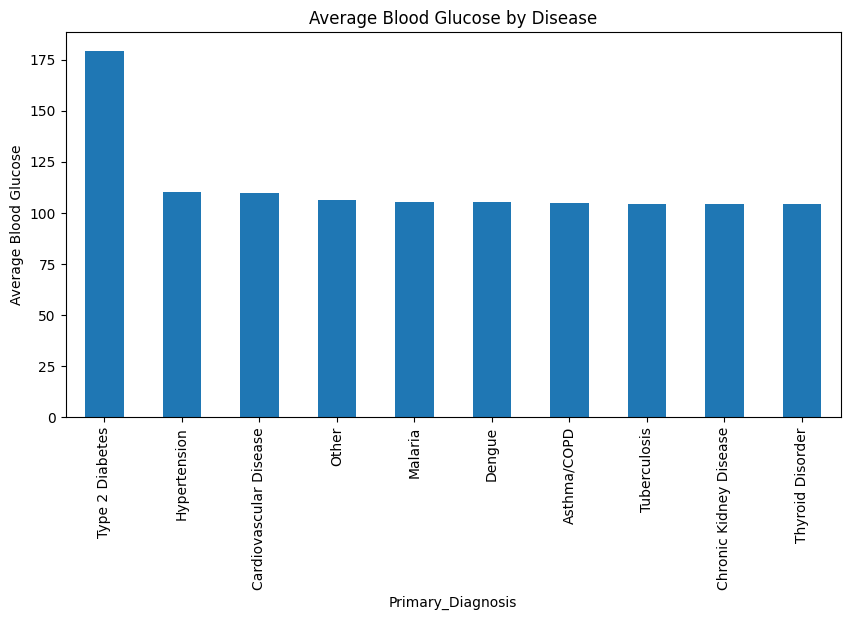

In [36]:
df.groupby("Primary_Diagnosis")["Blood_Glucose_mg_dL"]\
.mean()\
.sort_values(ascending=False)\
.plot(kind="bar", figsize=(10,5))

plt.title("Average Blood Glucose by Disease")
plt.ylabel("Average Blood Glucose")
plt.show()